<a href="https://colab.research.google.com/github/Saikat-too/Machine_Learning/blob/main/MAGIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [2]:
cols = ["fLength","fWidth","fSize","fConc","fConci","fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"]
df = pd.read_csv("magic04.data",names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConci,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
df["class"]=(df["class"]=="g").astype(int)

In [4]:
df.head()

,fLength,fWidth,fSize,fConc,fConci,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


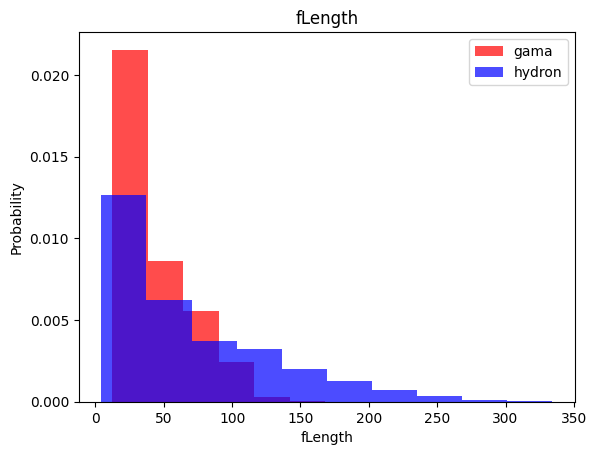

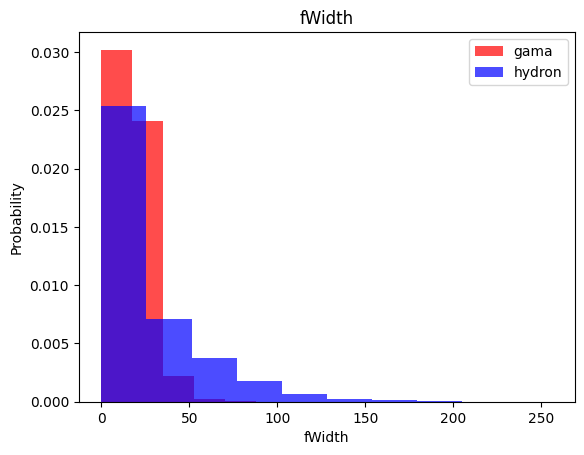

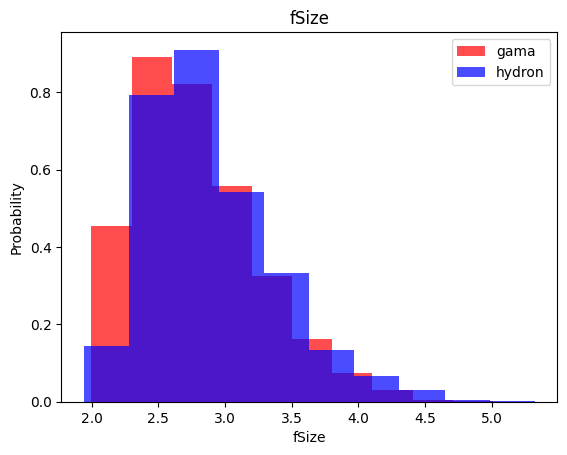

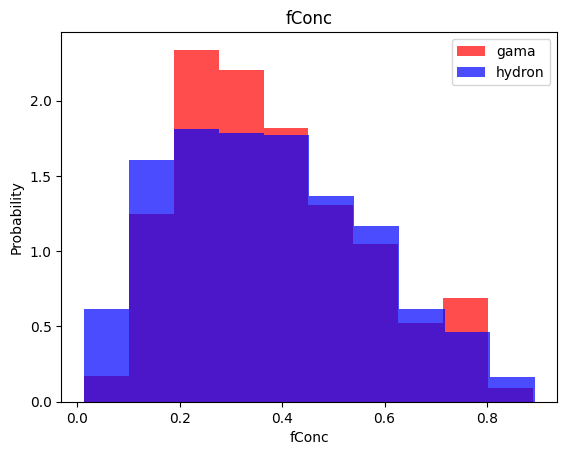

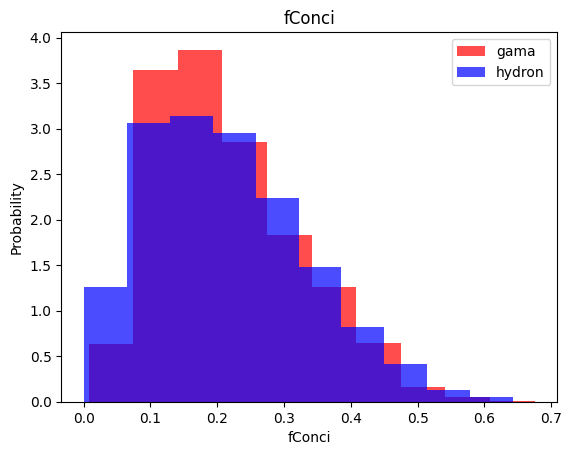

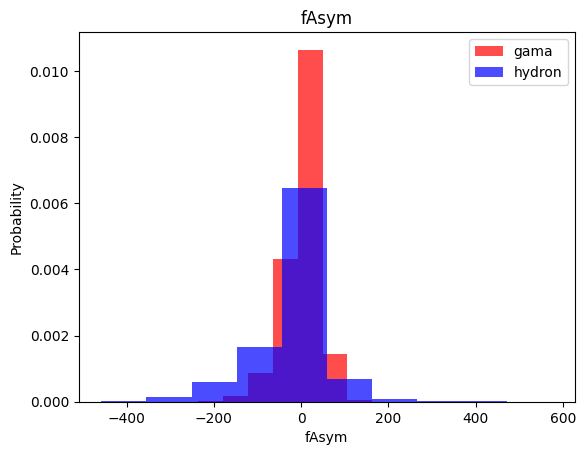

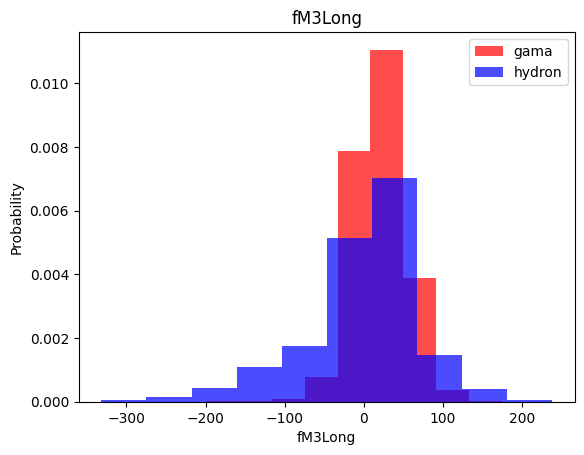

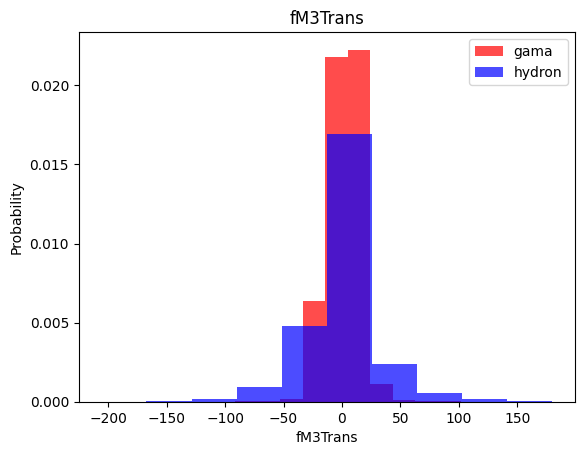

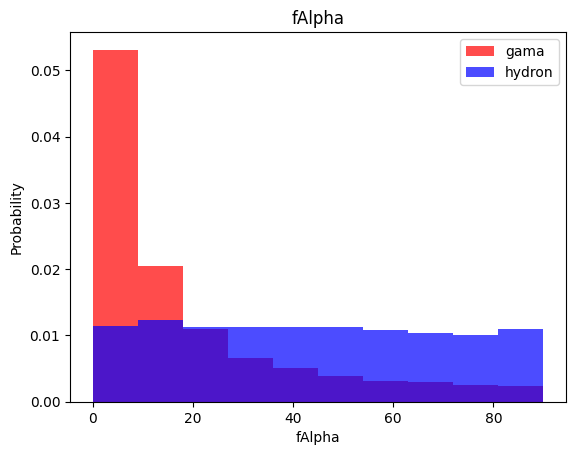

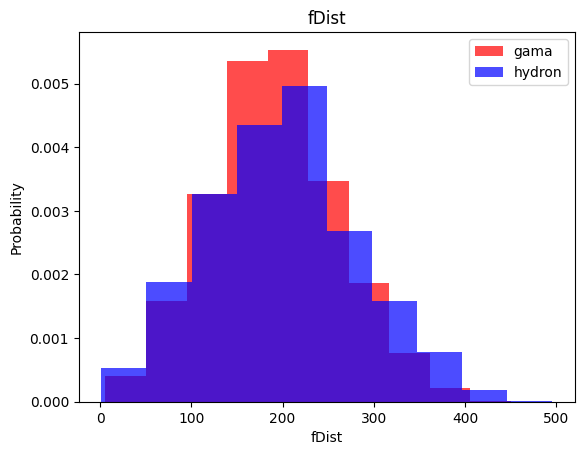

In [5]:
for label in cols[:-1]:
  plt.hist(df[df["class"]==1][label],color='red',label='gama',alpha=0.7,density=True)
  plt.hist(df[df["class"]==0][label],color='blue',label='hydron',alpha=0.7,density=True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

In [6]:
train,valid,test=np.split(df.sample(frac=1),[int(0.6*len(df)),int(0.8*len(df))])

In [7]:
def scale_dataset(dataframe,oversample=False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x=scaler.fit_transform(x)

  if oversample:
    ros = RandomOverSampler()
    x,y=ros.fit_resample(x,y)
  data = np.hstack((x,np.reshape(y,(-1,1))))

  return data,x,y



In [8]:
train , x_train , y_train = scale_dataset(train,oversample=True)
valid , x_valid , y_valid = scale_dataset(valid,oversample=False)
test, x_test , y_test = scale_dataset(test,oversample=False)

KNN Model

In [9]:
from sklearn.neighbors import  KNeighborsClassifier
from sklearn.metrics import classification_report

In [10]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(x_train,y_train)

KNeighborsClassifier()

In [11]:
y_pred = knn_model.predict(x_test)

In [12]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.75      0.76      1328
           1       0.87      0.88      0.87      2476

    accuracy                           0.83      3804
   macro avg       0.81      0.81      0.81      3804
weighted avg       0.83      0.83      0.83      3804



In [13]:
y_test

array([0, 1, 0, ..., 0, 1, 0])

Naive Bayes


In [14]:
from sklearn.naive_bayes import GaussianNB

In [15]:
nb_model = GaussianNB()
nb_model=nb_model.fit(x_train,y_train)


In [16]:
y_pred = nb_model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.70      0.41      0.52      1328
           1       0.74      0.90      0.81      2476

    accuracy                           0.73      3804
   macro avg       0.72      0.66      0.66      3804
weighted avg       0.73      0.73      0.71      3804



Log Regression


In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(x_train,y_train)

In [19]:
y_pred = lg_model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.73      0.68      0.70      1426
           1       0.81      0.85      0.83      2378

    accuracy                           0.78      3804
   macro avg       0.77      0.76      0.76      3804
weighted avg       0.78      0.78      0.78      3804



Support Vector Machines

In [20]:
from sklearn.svm import SVC

In [21]:
svm_model = SVC()
svm_model = svm_model.fit(x_train,y_train)

In [58]:
y_pred = svm_model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1328
           1       0.89      0.90      0.89      2476

    accuracy                           0.86      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.86      0.86      0.86      3804



Neural Network

In [23]:
import tensorflow as tf

In [28]:
def train_model(x_train,y_train,num_nodes,dropout_prob,lr,batch_size,epochs):
    nn_model=tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes,activation='relu',input_shape=(10,)),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes,activation='relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1,activation='sigmoid')
    ])

    nn_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),loss='binary_crossentropy',metrics=['accuracy'])

    history = nn_model.fit(
        x_train,y_train,epochs=epochs,batch_size=batch_size,validation_split=0.2,verbose=0
    )
    return nn_model,history

In [38]:
def plot_history(history):
  fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,12))
  ax1.plot(history.history['loss'],label='loss')
  ax1.plot(history.history['val_loss'],label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy')
  ax1.grid(True)

  ax2.plot(history.history['accuracy'],label='accuracy')
  ax2.plot(history.history['val_accuracy'],label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.grid(True)

  plt.show()

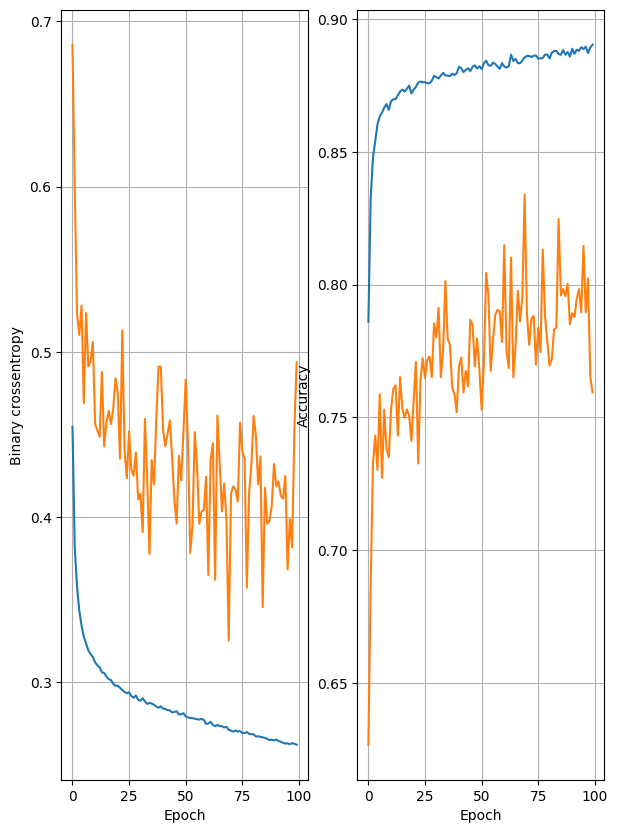

In [37]:
plot_history(history)

64 nodes,dropout 0, lr 0.005 , batch size 32


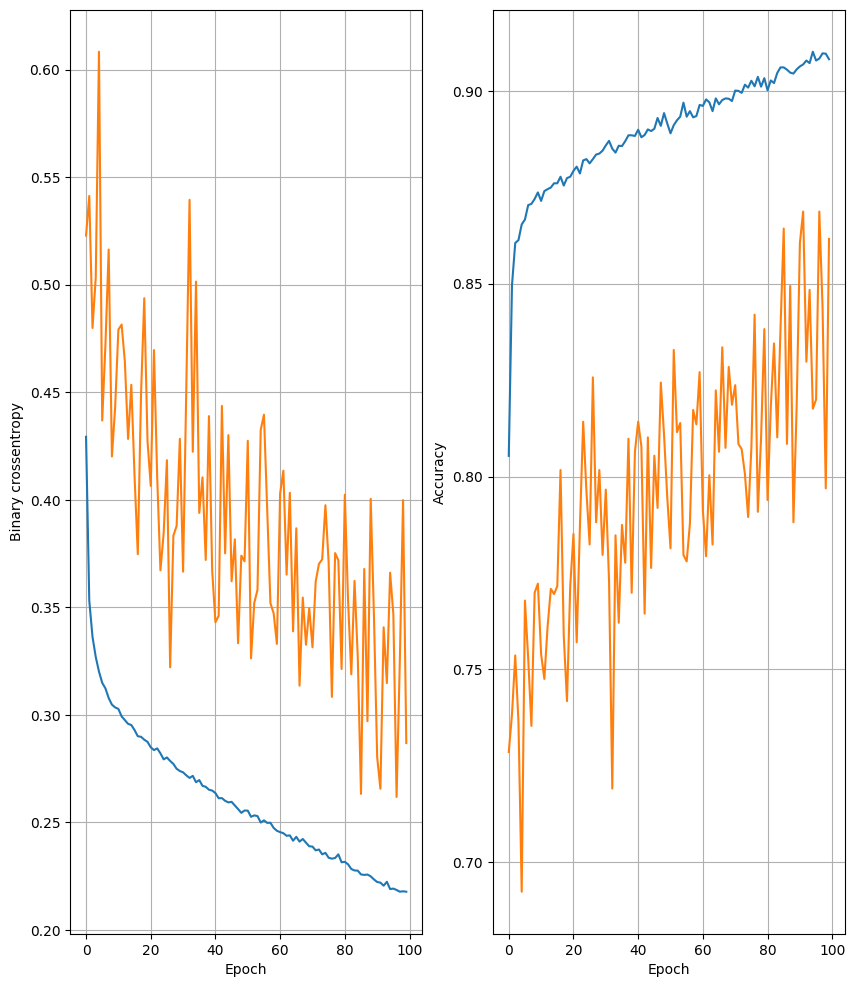

119/119 [==============================] - 0s 2ms/step - loss: 0.3642 - accuracy: 0.8594
64 nodes,dropout 0, lr 0.005 , batch size 64


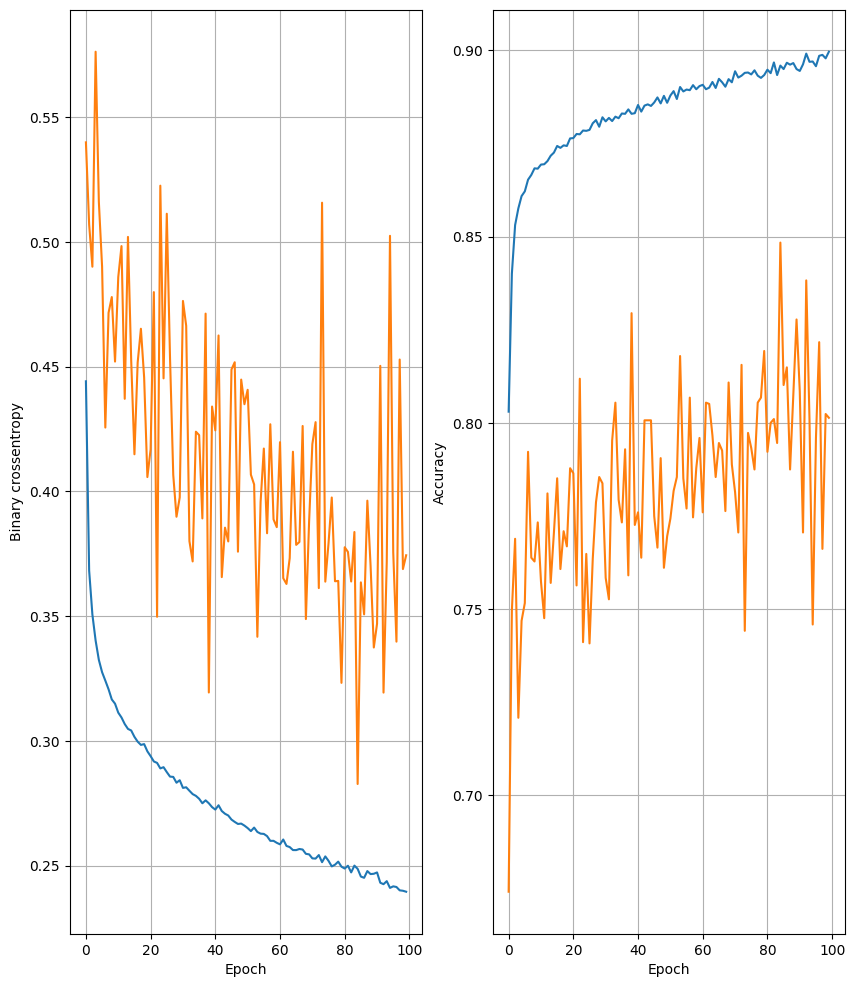

119/119 [==============================] - 0s 2ms/step - loss: 0.3347 - accuracy: 0.8665
64 nodes,dropout 0, lr 0.005 , batch size 128


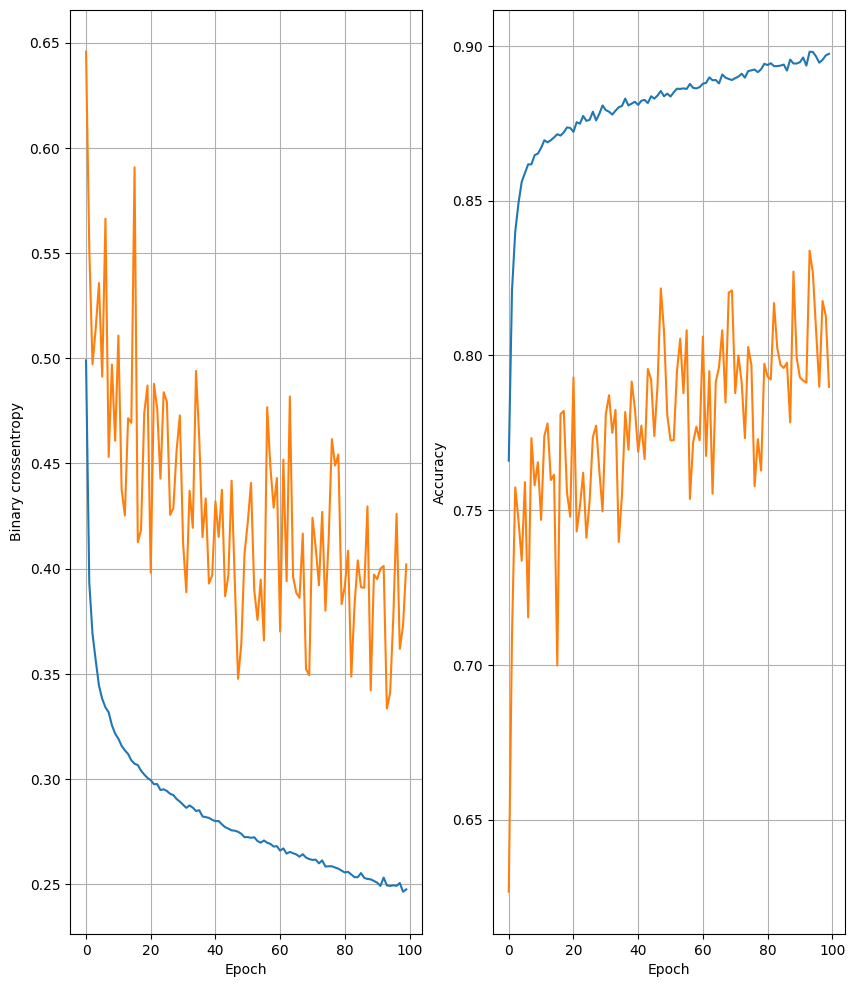

119/119 [==============================] - 0s 2ms/step - loss: 0.3274 - accuracy: 0.8644
64 nodes,dropout 0, lr 0.001 , batch size 32


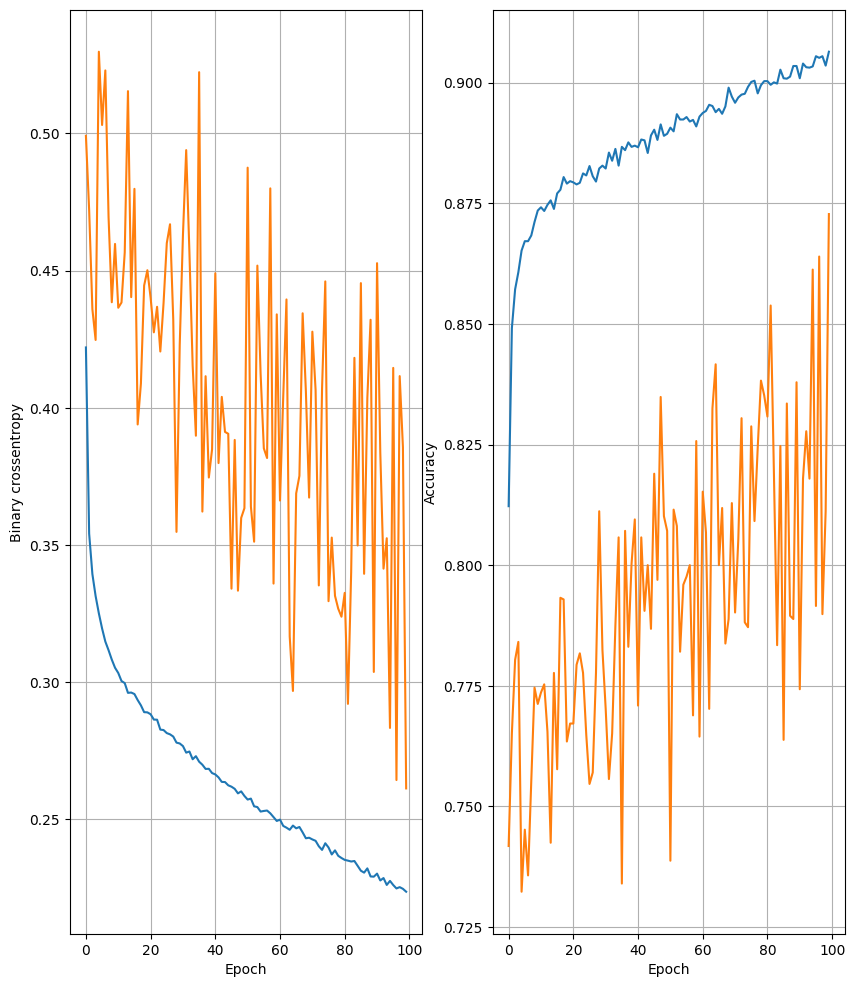

119/119 [==============================] - 0s 2ms/step - loss: 0.3655 - accuracy: 0.8538
64 nodes,dropout 0, lr 0.001 , batch size 64


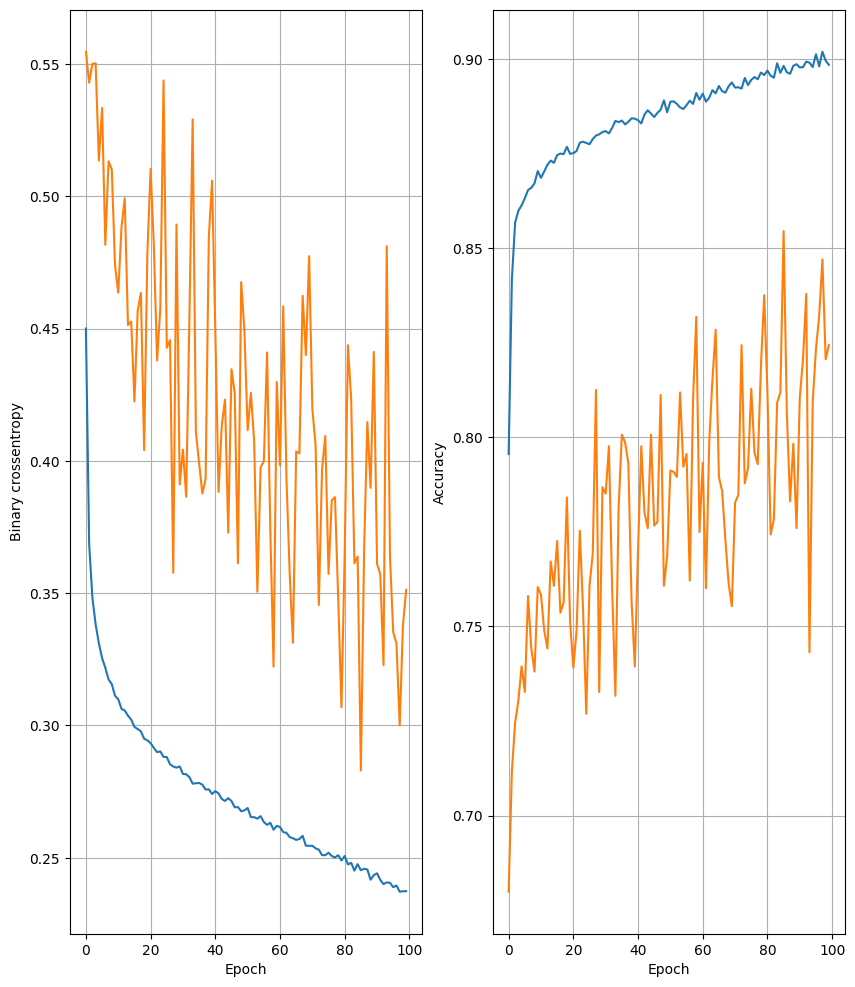

119/119 [==============================] - 0s 2ms/step - loss: 0.3354 - accuracy: 0.8596
64 nodes,dropout 0, lr 0.001 , batch size 128


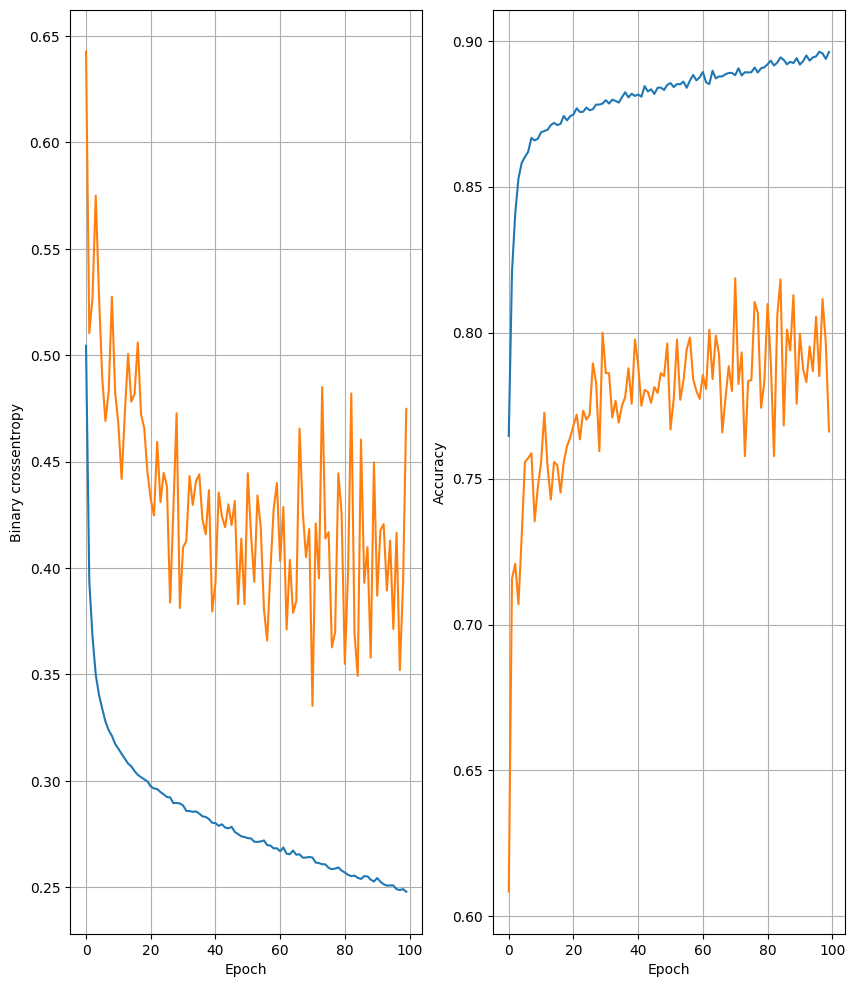

119/119 [==============================] - 0s 2ms/step - loss: 0.3262 - accuracy: 0.8657
64 nodes,dropout 0.2, lr 0.005 , batch size 32


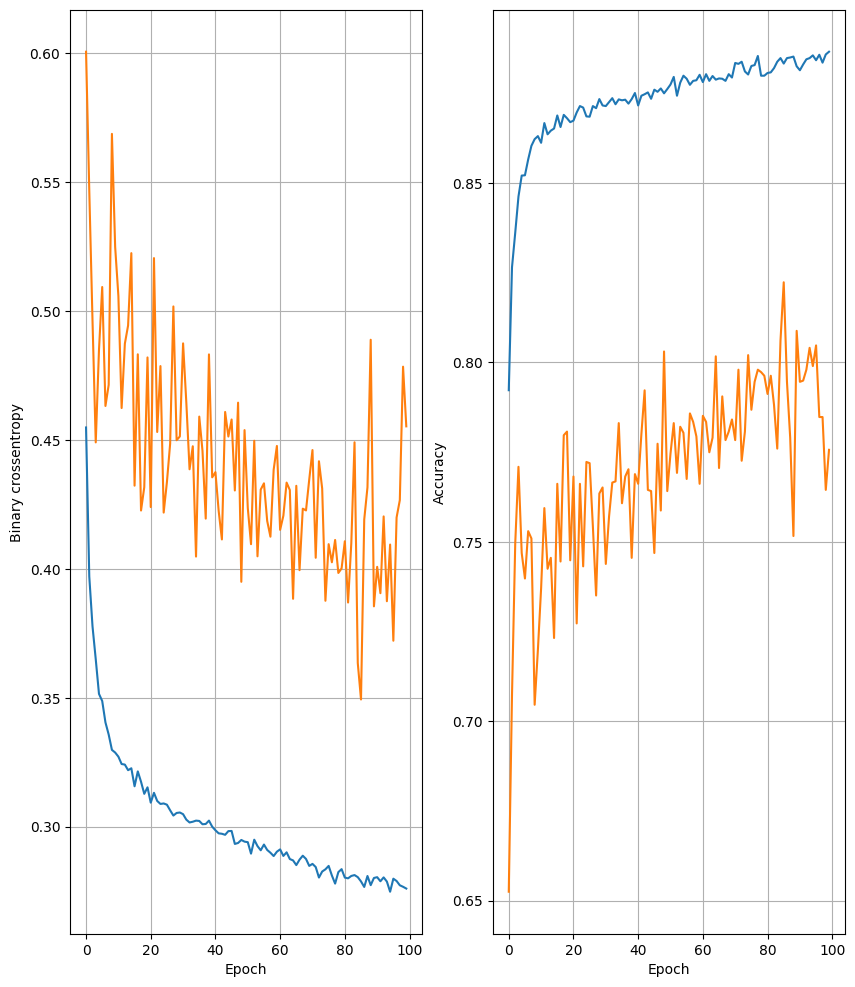

119/119 [==============================] - 0s 2ms/step - loss: 0.3010 - accuracy: 0.8722
64 nodes,dropout 0.2, lr 0.005 , batch size 64


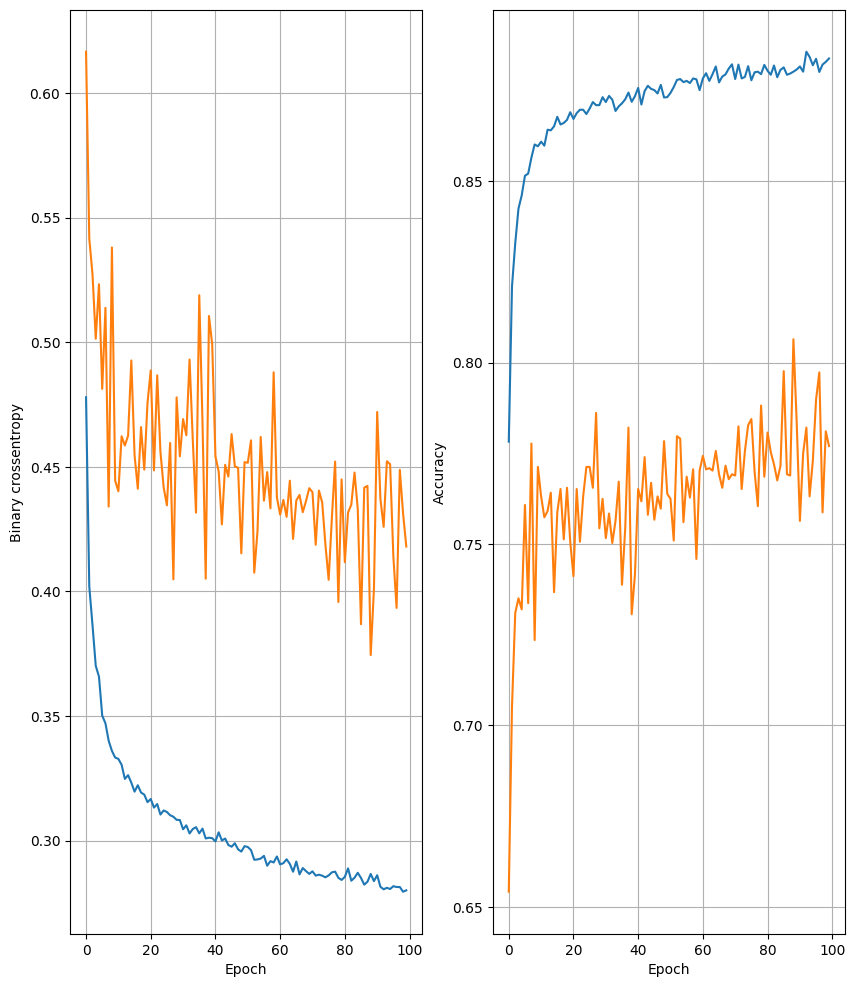

119/119 [==============================] - 0s 2ms/step - loss: 0.3060 - accuracy: 0.8688
64 nodes,dropout 0.2, lr 0.005 , batch size 128


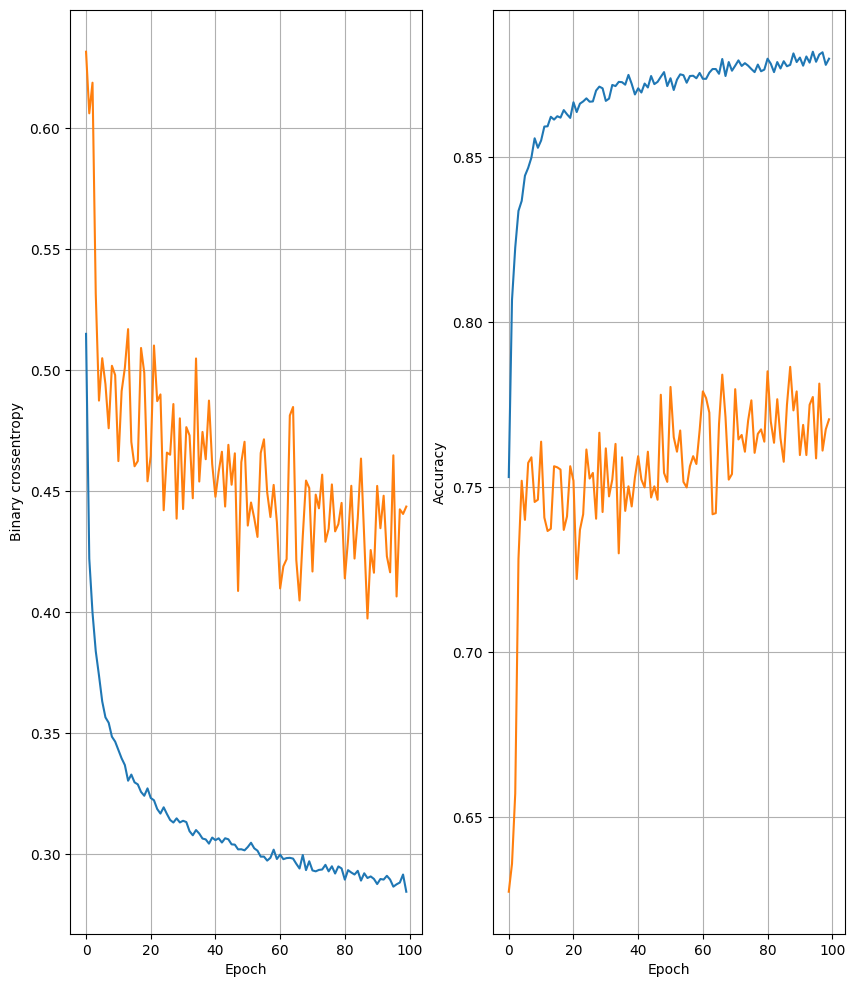

119/119 [==============================] - 0s 2ms/step - loss: 0.3055 - accuracy: 0.8696
64 nodes,dropout 0.2, lr 0.001 , batch size 32


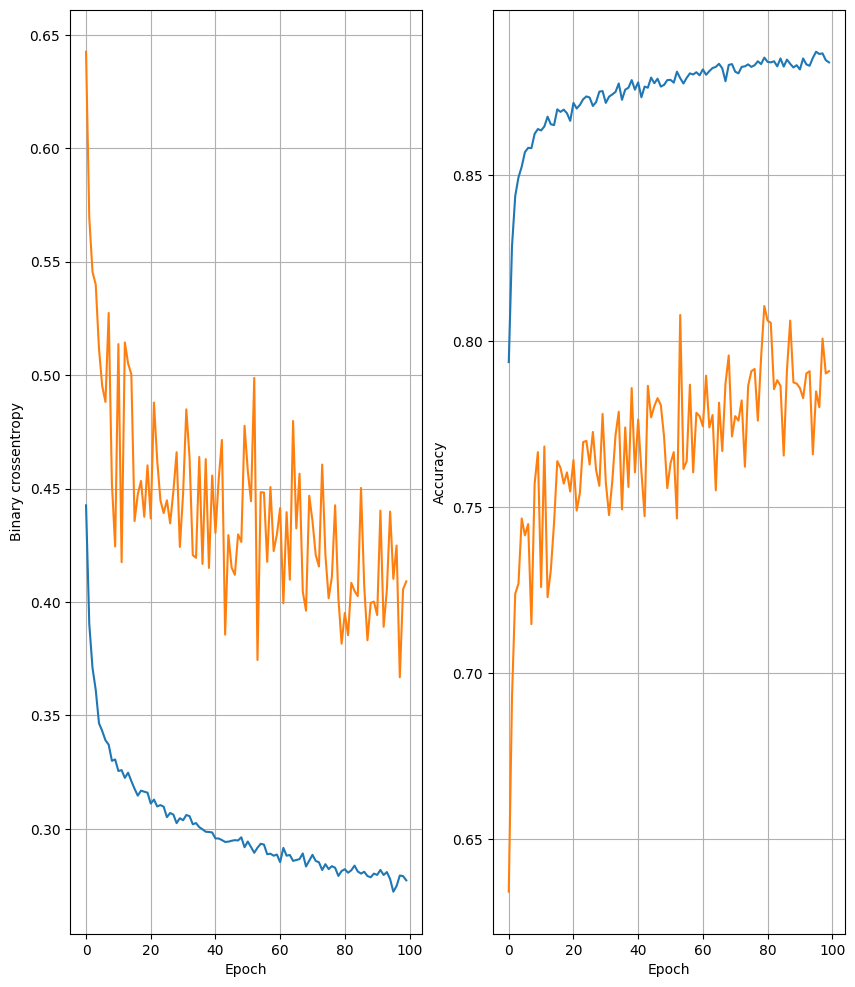

119/119 [==============================] - 0s 2ms/step - loss: 0.3002 - accuracy: 0.8712
64 nodes,dropout 0.2, lr 0.001 , batch size 64


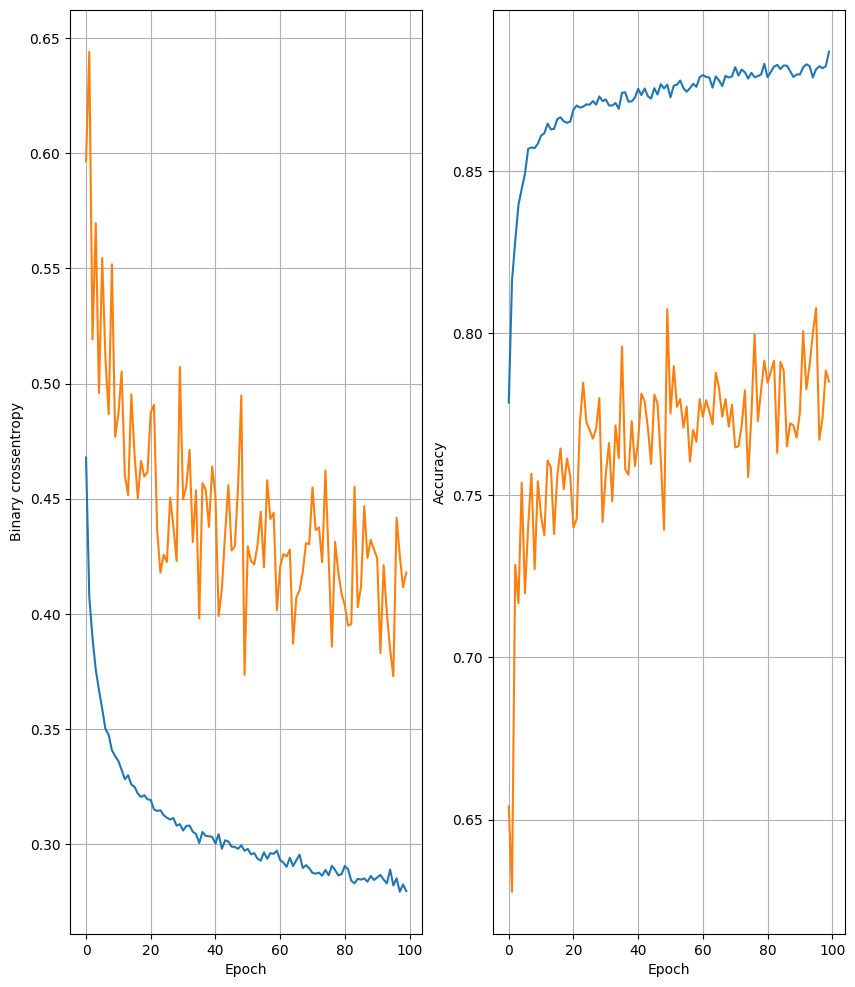

119/119 [==============================] - 0s 2ms/step - loss: 0.3038 - accuracy: 0.8696
64 nodes,dropout 0.2, lr 0.001 , batch size 128


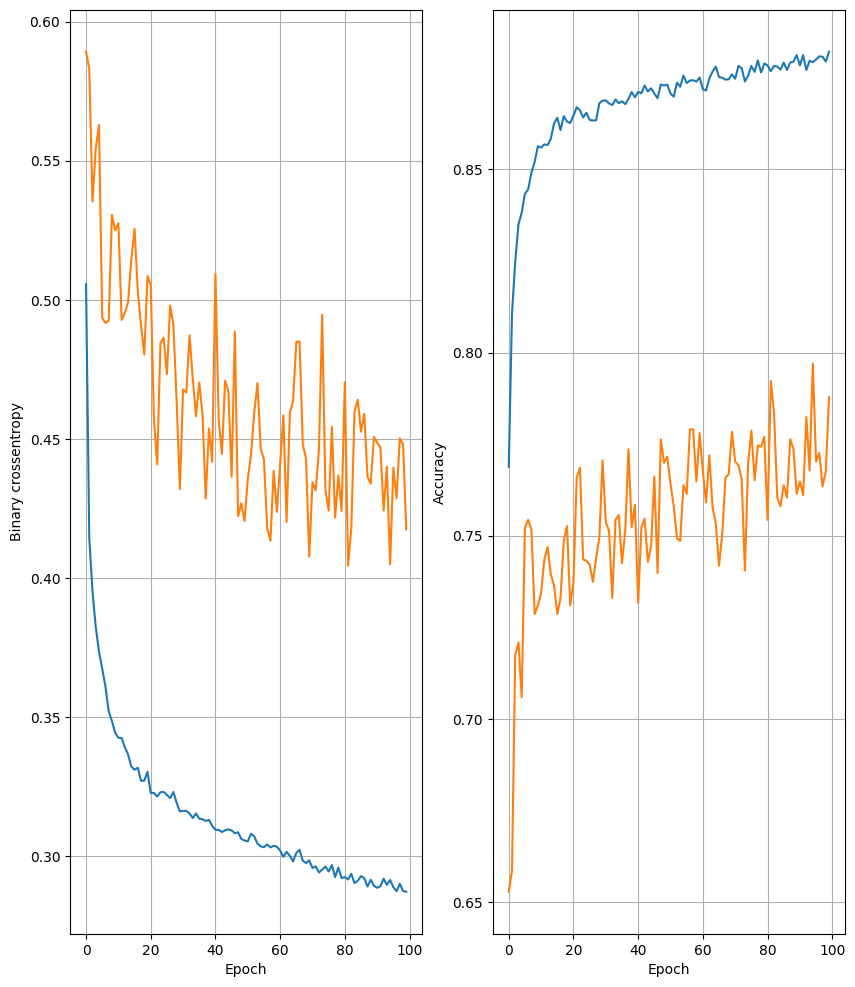

119/119 [==============================] - 0s 2ms/step - loss: 0.3061 - accuracy: 0.8720


In [44]:
epochs = 100
least_val_loss = float('inf')
least_loss_model = None
for num_nodes in [64]:
  for dropout_prob in [0,0.2]:
    for lr in [0.005,0.001]:
      for batch_size in [32,64,128]:
        print(f"{num_nodes} nodes,dropout {dropout_prob}, lr {lr} , batch size { batch_size}")
        model,history = train_model(x_train,y_train,num_nodes,dropout_prob,lr,batch_size,epochs)
        plot_history(history)
        val_loss = model.evaluate(x_valid,y_valid)[0]
        if val_loss <least_val_loss:
          least_val_loss = val_loss
          least_loss_model = model

In [54]:
y_pred = least_loss_model.predict(x_test)
y_pred = (y_pred>0.5).astype(int).reshape(-1,)
print(y_pred)

119/119 [==============================] - 1s 4ms/step
[0 1 0 ... 0 1 0]


In [56]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1328
           1       0.88      0.95      0.91      2476

    accuracy                           0.88      3804
   macro avg       0.88      0.85      0.87      3804
weighted avg       0.88      0.88      0.88      3804

